# XGBoost Classification – NB1: Baseline

## Goal
Predict **`meat_type`** (classes 1–5) from all other features using `XGBClassifier`.

## Benchmarks to beat

| Model | Acc Test | Acc Stress |
|---|---|---|
| Decision Tree baseline | 53.0% | 27% |
| Random Forest baseline (KNN imputation) | 56.0% | 24% |
| RF + target encoding (best so far) | 62.5% | 25% |

## What is new in this notebook
1. **XGBoost** instead of Random Forest: boosting builds trees *sequentially*, each new tree corrects the errors of the previous ones.
2. **Native NaN handling**: XGBoost can train and predict with missing values. At every split it learns a *default direction* for NaN. Decision Tree and Random Forest could not do this, so we compare **native NaN vs. median fill** on the stress test.

## Steps
1. Imports
2. Load and inspect data
3. Label shift (1–5 → 0–4)
4. Train/test split
5. Train the model
6. Evaluate on the internal test set
7. Feature importance
8. Prepare the stress test
9. Stress test: native NaN vs. median fill
10. Detailed stress-test analysis
11. Comparison with previous models

## Step 1 – Imports

- `xgboost.XGBClassifier` – the model
- `sklearn` – split and metrics
- `matplotlib` / `seaborn` – plots

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## Step 2 – Load and inspect the data

Before modelling we check:
- **Shape** – how many rows and columns
- **Missing values** – the training data should be clean, the stress test contains NaN on purpose
- **Class balance** – if one class dominated, accuracy would be misleading

In [28]:
df = pd.read_csv("meat_price_dataset.csv")
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print("Training data:", df.shape)
print("Stress data:  ", df_stress.shape)

print("\nMissing values (stress test):")
print(df_stress.isna().sum())

print("\nClass distribution (training data):")
print(df["meat_type"].value_counts().sort_index())

Training data: (1200, 9)
Stress data:   (100, 9)

Missing values (stress test):
meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64

Class distribution (training data):
meat_type
1    251
2    200
3    263
4    248
5    238
Name: count, dtype: int64


**Observation:** The training data has no missing values and the 5 classes are roughly balanced (200–263 rows each). Accuracy is therefore a fair metric, and random guessing would give ~20%.

## Step 3 – Label shift (1–5 → 0–4)

`XGBClassifier` requires class labels to be consecutive integers **starting at 0**. Our `meat_type` runs from 1 to 5, so we subtract 1 before training.

| Original meat_type | XGBoost label |
|---|---|
| 1 | 0 |
| 2 | 1 |
| 3 | 2 |
| 4 | 3 |
| 5 | 4 |

For reporting we add 1 back, so all results stay comparable with the Decision Tree and Random Forest notebooks.

In [29]:
TARGET = "meat_type"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET].astype(int) - 1   # 1-5 -> 0-4

CLASS_NAMES = ["1", "2", "3", "4", "5"]   # original labels for reports

print("Features:", FEATURES)
print("Labels after shift:", sorted(y.unique()))

Features: ['fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality', 'price_eur_per_kg']
Labels after shift: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## Step 4 – Train/test split

- **80% training, 20% test**
- **`stratify=y`** keeps the same class proportions in both sets (classification only)
- Same `random_state=42` as all previous notebooks, so the test set is identical and the results are comparable

We keep the 8 raw features. No engineered ratios, because the Decision Tree experiments showed they add noise, not signal.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (960, 8)  Test: (240, 8)


## Step 5 – Train the model

### Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `objective` | `multi:softprob` | Multi-class classification; outputs one probability per class |
| `num_class` | 5 | Number of classes (set automatically by the sklearn API) |
| `n_estimators` | 150 | Number of boosting rounds (trees) |
| `learning_rate` | 0.08 | How strongly each new tree corrects the previous ones |
| `max_depth` | 5 | Maximum depth of each tree |
| `eval_metric` | `mlogloss` | Multi-class log loss, measures how confident *and* correct the probabilities are |

These are the **same hyperparameters as the XGBoost regression notebooks**. Tuning comes later (NB5), so this notebook stays a clean baseline.

### How boosting differs from Random Forest
- **Random Forest:** 200 independent trees, each on random data, predictions averaged.
- **XGBoost:** trees built one after another. Tree 2 focuses on what tree 1 got wrong, tree 3 on what trees 1+2 got wrong, and so on.

For multi-class, XGBoost builds **one tree per class per round**, so 150 rounds × 5 classes = 750 trees in total.

In [31]:
model = XGBClassifier(
    objective="multi:softprob",
    n_estimators=150,
    learning_rate=0.08,
    max_depth=7,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 6 – Evaluate on the internal test set

We compare **train accuracy vs. test accuracy**:
- Both high and close together → the model generalises well
- Train much higher than test → **overfitting** (the model memorised the training data)

Then we look at the per-class report. The critical question from earlier notebooks: **do the middle classes 2, 3 and 4 improve?**

In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {acc_train:.2%}")
print(f"Test accuracy:  {acc_test:.2%}")
print(f"Gap:            {acc_train - acc_test:.2%}")

print("\nClassification report (internal test):")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, digits=2))

Train accuracy: 100.00%
Test accuracy:  65.42%
Gap:            34.58%

Classification report (internal test):
              precision    recall  f1-score   support

           1       0.75      0.76      0.75        50
           2       0.55      0.57      0.56        40
           3       0.51      0.42      0.46        52
           4       0.53      0.60      0.56        50
           5       0.94      0.92      0.93        48

    accuracy                           0.65       240
   macro avg       0.65      0.65      0.65       240
weighted avg       0.65      0.65      0.65       240



### Confusion matrix

Rows = true class, columns = predicted class. The diagonal shows correct predictions. Values next to the diagonal show confusion between **neighbouring** classes (e.g. 3 predicted as 4), which is the price-overlap problem we saw with DT and RF.

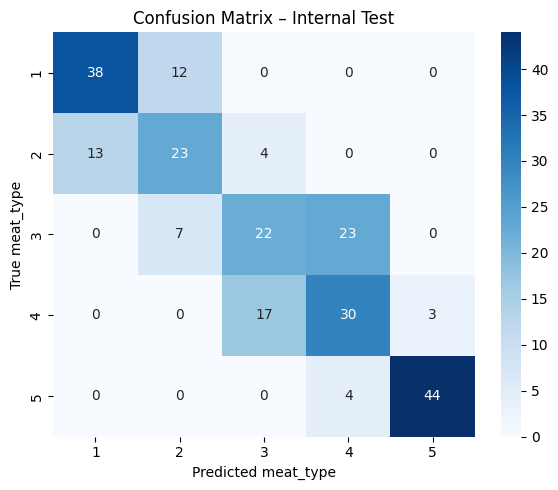

In [33]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted meat_type")
plt.ylabel("True meat_type")
plt.title("Confusion Matrix – Internal Test")
plt.tight_layout()
plt.show()

## Step 7 – Feature importance

XGBoost offers several importance types. We use **`gain`**: the average improvement in loss a feature brings when it is used for a split. It is the closest equivalent to the importance values reported for DT and RF.

For comparison:
- Decision Tree (regression): `meat_type` 70%
- RF classification baseline: `price_eur_per_kg` 52%
- RF + target encoding: `price_eur_per_kg` 33.7% + `price_bin_te` 21.6%

price_eur_per_kg     30.6 %
cut_quality          17.2 %
organic              13.0 %
marbling_score       10.3 %
fat_content_pct       7.6 %
animal_age_months     7.5 %
storage_days          7.4 %
protein_pct           6.3 %
dtype: object


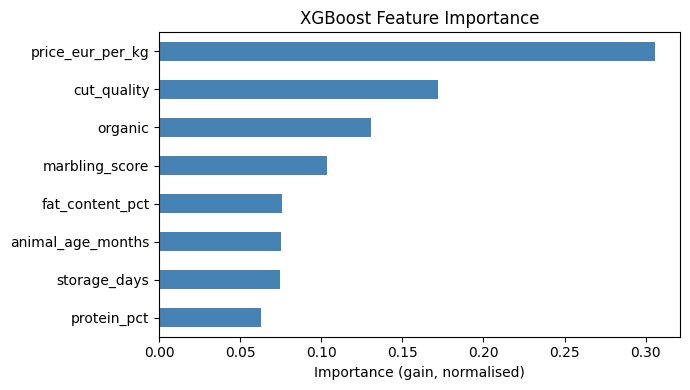

In [34]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

print((importance * 100).round(1).astype(str) + " %")

plt.figure(figsize=(7, 4))
importance.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Importance (gain, normalised)")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

## Step 8 – Prepare the stress test

The stress test has 100 rows with missing values and outliers.

**Rows with missing `meat_type` must be dropped.** `meat_type` is our target. Without a true label we cannot check whether a prediction is right. (Filling the target would mean grading the model against our own guess.) This leaves 91 rows.

After that we apply the same label shift as for the training data.

In [35]:
stress = df_stress.dropna(subset=[TARGET]).copy()
print(f"Stress rows: {len(df_stress)} -> {len(stress)} after dropping missing targets")

X_stress = stress[FEATURES]
y_stress = stress[TARGET].astype(int) - 1

print("\nRemaining missing values in features:")
print(X_stress.isna().sum())

print("\nClass distribution (stress test):")
print((y_stress + 1).value_counts().sort_index())

Stress rows: 100 -> 91 after dropping missing targets

Remaining missing values in features:
fat_content_pct      10
protein_pct          10
marbling_score        8
animal_age_months     6
storage_days          8
organic               9
cut_quality           7
price_eur_per_kg      8
dtype: int64

Class distribution (stress test):
meat_type
1    18
2    17
3    12
4    25
5    19
Name: count, dtype: int64


## Step 9 – Stress test: native NaN vs. median fill

We run two experiments with the **same trained model**:

| Variant | How NaN are handled |
|---|---|
| **A – Native NaN** | No filling. XGBoost sends each NaN down the *default branch* it learned at every split. |
| **B – Median fill** | NaN replaced by the **training-set median** of that feature (the approach used in the DT/RF baselines). |

**Important note on variant A:** our training data has **no** NaN at all. XGBoost therefore never saw a missing value during training, and the default directions are chosen without real evidence. That is exactly what this experiment tests: is the untrained default better or worse than a median?

**Note on leakage:** we use the global median, **not** the median per `meat_type`. Grouping by `meat_type` would use the target to fill the features, which leaks the answer into the input.

In [36]:
# Variant A – native NaN handling
y_pred_native = model.predict(X_stress)
acc_native = accuracy_score(y_stress, y_pred_native)

# Variant B – median fill from training data only
train_medians = X_train.median()
X_stress_median = X_stress.fillna(train_medians)
y_pred_median = model.predict(X_stress_median)
acc_median = accuracy_score(y_stress, y_pred_median)

results_stress = pd.DataFrame({
    "Variant": ["A – Native NaN", "B – Median fill"],
    "Accuracy": [acc_native, acc_median],
    "Macro F1": [
        f1_score(y_stress, y_pred_native, average="macro"),
        f1_score(y_stress, y_pred_median, average="macro"),
    ],
})
results_stress["Accuracy"] = (results_stress["Accuracy"] * 100).round(2).astype(str) + " %"
results_stress["Macro F1"] = results_stress["Macro F1"].round(3)
print(results_stress.to_string(index=False))

        Variant Accuracy  Macro F1
 A – Native NaN  21.98 %     0.169
B – Median fill  19.78 %     0.151


## Step 10 – Detailed stress-test analysis

We take the better of the two variants and look at the per-class report and confusion matrix. Questions to answer:
- Do the **extreme classes 1 and 5** still work (clear price boundaries)?
- Does the model collapse toward one "catch-all" class, as the Decision Tree did with class 3?

Best stress variant: Native NaN

              precision    recall  f1-score   support

           1       1.00      0.11      0.20        18
           2       0.17      0.06      0.09        17
           3       0.06      0.08      0.07        12
           4       0.06      0.04      0.05        25
           5       0.31      0.79      0.44        19

    accuracy                           0.22        91
   macro avg       0.32      0.22      0.17        91
weighted avg       0.32      0.22      0.17        91



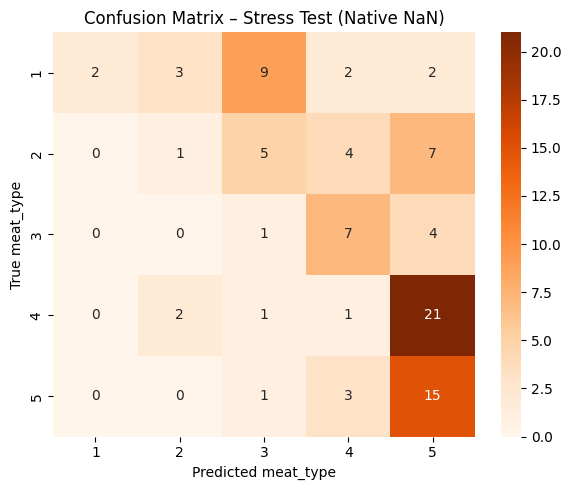

In [37]:
if acc_native >= acc_median:
    best_name, y_pred_best = "Native NaN", y_pred_native
else:
    best_name, y_pred_best = "Median fill", y_pred_median

print(f"Best stress variant: {best_name}\n")
print(classification_report(y_stress, y_pred_best, labels=range(5),
                            target_names=CLASS_NAMES, digits=2, zero_division=0))

cm_stress = confusion_matrix(y_stress, y_pred_best, labels=range(5))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_stress, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted meat_type")
plt.ylabel("True meat_type")
plt.title(f"Confusion Matrix – Stress Test ({best_name})")
plt.tight_layout()
plt.show()

### Where do stress-test values leave the training range?

A tree model cannot extrapolate. Any value above the training maximum ends up in the same leaf as the maximum itself. This table shows how many stress rows exceed the training range per feature. These are the candidates for **outlier clipping in NB2**.

In [38]:
train_min, train_max = X_train.min(), X_train.max()

out_of_range = pd.DataFrame({
    "train_min": train_min,
    "train_max": train_max,
    "stress_min": X_stress.min(),
    "stress_max": X_stress.max(),
    "rows_below": (X_stress < train_min).sum(),
    "rows_above": (X_stress > train_max).sum(),
})
print(out_of_range)

                   train_min  train_max  stress_min  stress_max  rows_below  rows_above
fat_content_pct         2.00      35.00        2.00        58.5           0           3
protein_pct            15.00      26.00       15.10        25.0           0           0
marbling_score          1.00      10.00        0.00        12.0           1           1
animal_age_months       2.00      71.00        2.00       189.0           0           2
storage_days            0.00      20.00        0.00        80.0           0           2
organic                 0.00       1.00        0.00         1.0           0           0
cut_quality             1.00       5.00        1.00         5.0           0           0
price_eur_per_kg        3.18      43.33       12.14        65.4           0           4


## Step 11 – Comparison with previous models

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "DT baseline",
        "RF baseline (KNN)",
        "RF + target encoding",
        "XGB baseline – native NaN",
        "XGB baseline – median fill",
    ],
    "Acc Test": ["53.0 %", "56.0 %", "62.5 %", f"{acc_test*100:.1f} %", f"{acc_test*100:.1f} %"],
    "Acc Stress": ["27 %", "24 %", "25 %", f"{acc_native*100:.1f} %", f"{acc_median*100:.1f} %"],
})
print(comparison.to_string(index=False))

                     Model Acc Test Acc Stress
               DT baseline   53.0 %       27 %
         RF baseline (KNN)   56.0 %       24 %
      RF + target encoding   62.5 %       25 %
 XGB baseline – native NaN   65.4 %     22.0 %
XGB baseline – median fill   65.4 %     19.8 %


## Summary and next steps

Interpret the printed results with these questions:

1. **Internal test:** Does XGBoost beat the RF baseline (56%) *without* target encoding? Is it close to RF + target encoding (62.5%)?
2. **Overfitting:** How big is the train/test gap? A large gap means boosting memorises the training data, as seen in the regression (train RMSE 0.39 vs. test RMSE 1.30).
3. **Middle classes:** Did classes 2, 3 and 4 improve compared to DT (F1 0.39 / 0.49 / 0.24)?
4. **Native NaN vs. median:** Which works better when the model never saw NaN during training?
5. **Out-of-range values:** How many stress rows fall outside the training range?

### Next notebooks
- **NB2 – Imputation + clipping:** leakage-free imputation (no grouping by the target) and clipping to training bounds
- **NB3 – Target encoding:** the technique that gave RF its best result
- **NB4 – Combined dataset training:** the regression breakthrough (stress R² −0.36 → +0.20)
- **NB5 – Hyperparameter tuning:** RandomizedSearchCV with StratifiedKFold